In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

Note: The quantified effects represent conditional demand deviations rather than additive contributions. Interactions between variables may influence demand jointly, as illustrated by the temperature–humidity analysis.

# Data Loading and Helper function

In [2]:
df = pd.read_csv("hour.csv")
print(df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [3]:
def plot1(lags, data, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ACF
    plot_acf(
        data,
        lags=lags,
        ax=axes[0],
        alpha=0.05,      # confidence band alpha
        marker='o',
        markersize=3
    )
    axes[0].set_title(f"ACF {title}")
    axes[0].set_xlabel("Lag (hours)")
    axes[0].set_ylabel("Autocorrelation")

    # PACF
    plot_pacf(
        data,
        lags=lags,
        method='ywm',
        ax=axes[1],
        alpha=0.05,
        marker='o',
        markersize=3
    )
    axes[1].set_title(f"PACF {title}")
    axes[1].set_xlabel("Lag (hours)")
    axes[1].set_ylabel("Partial Autocorrelation")

    # Make points smaller + lighter
    for ax in axes:
        for line in ax.lines:
            line.set_markersize(3)   # smaller dots
            line.set_alpha(0.5)      # more transparent

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

# plot1(200, train['cnt'], "train bike count", "test.jpg")

# Part 1: Isolating Demand Deviations from Time Series Structure

Key idea:  
**Demand = trend + seasonal structure + demand deviations**

Demand deviations represent short-term fluctuations after removing trend and seasonality, capturing the impact of external factors such as weather and other unobserved influences. We focus on isolating this component for downstream analysis.

## 1.1 Evidence of Evolving Seasonal Patterns

### 1.1.1 Evidence from Train–Test Seasonal Mean Shift

In [4]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 13903
Test size: 3476


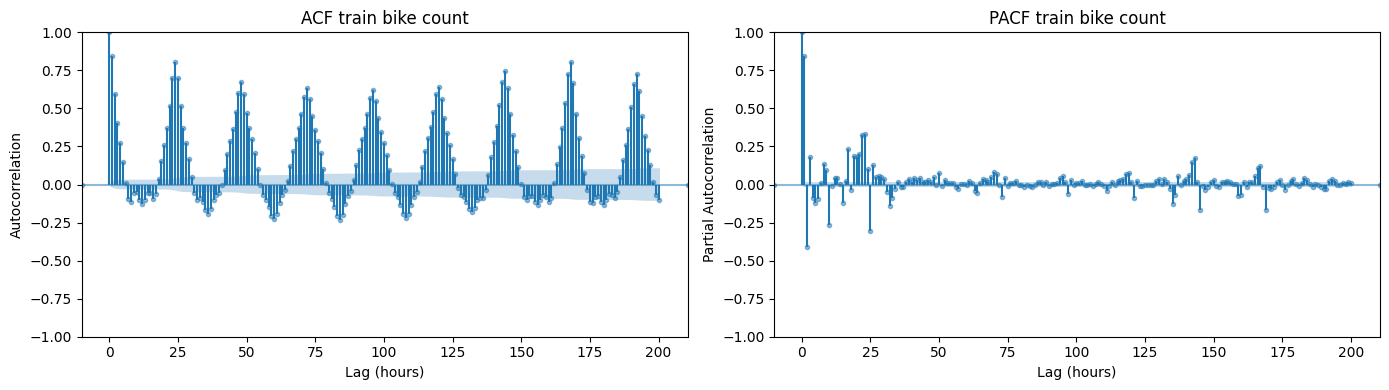

In [5]:
plot1(200, train['cnt'], "train bike count")

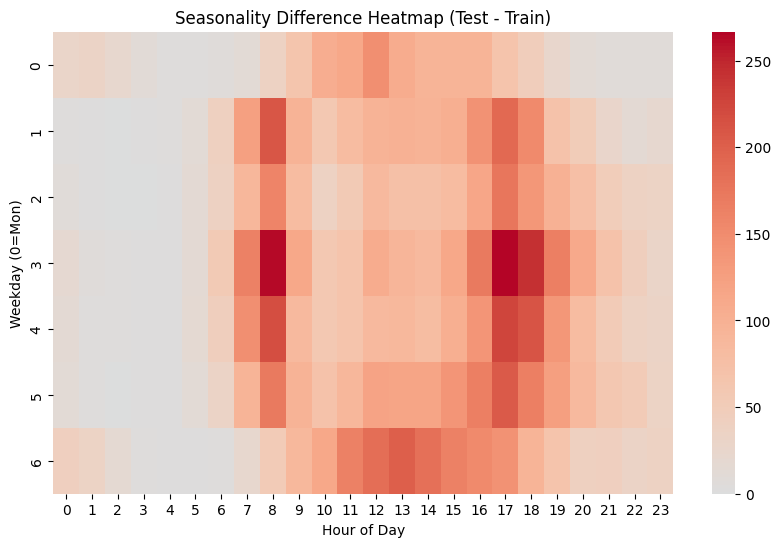

In [6]:
# Compute weekday × hour interactions
season_train = train.groupby(["weekday", "hr"])["cnt"].mean().unstack()
season_test  = test.groupby(["weekday", "hr"])["cnt"].mean().unstack()

season_diff = season_test - season_train

# plt.figure(figsize=(12,5))
# plt.plot(season_train.values.flatten(), alpha=0.7, label="Train weekday×hour mean")
# plt.plot(season_test.values.flatten(), alpha=0.7, label="Test weekday×hour mean")
# plt.title("Weekday × Hour Seasonal Pattern: Train vs Test")
# plt.legend()
# plt.show()

# Heatmap of differences (much more useful)
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(season_diff, cmap="coolwarm", center=0)
plt.title("Seasonality Difference Heatmap (Test - Train)")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday (0=Mon)")
plt.show()

Analysis:
- During earlier ARMA modeling, we observed that the seasonal mean differed between train and test sets, indicating that seasonal structure shifts over time rather than remaining fixed.

### 1.1.2 Seasonal Mean Shift Across Time Periods

In [7]:
df["period"] = df["yr"].astype(str) + "_H" + (df["mnth"] > 6).astype(int).add(1).astype(str)
seasonal_surface = (
    df.groupby(["period", "weekday", "hr"])["cnt"]
      .mean()
      .reset_index()
)
periods = df["period"].unique()

In [8]:
results = []

baseline_period = "0_H1"

for weekday in range(7):
    for hr in range(24):

        base = df[
            (df.period == baseline_period) &
            (df.weekday == weekday) &
            (df.hr == hr)
        ]["cnt"]

        for p in periods:

            if p == baseline_period:
                continue

            sample = df[
                (df.period == p) &
                (df.weekday == weekday) &
                (df.hr == hr)
            ]["cnt"]

            stat, pval = mannwhitneyu(base, sample)

            results.append({
                "period": p,
                "weekday": weekday,
                "hr": hr,
                "pval": pval,
                "median_diff": sample.median() - base.median()
            })

results_df = pd.DataFrame(results)

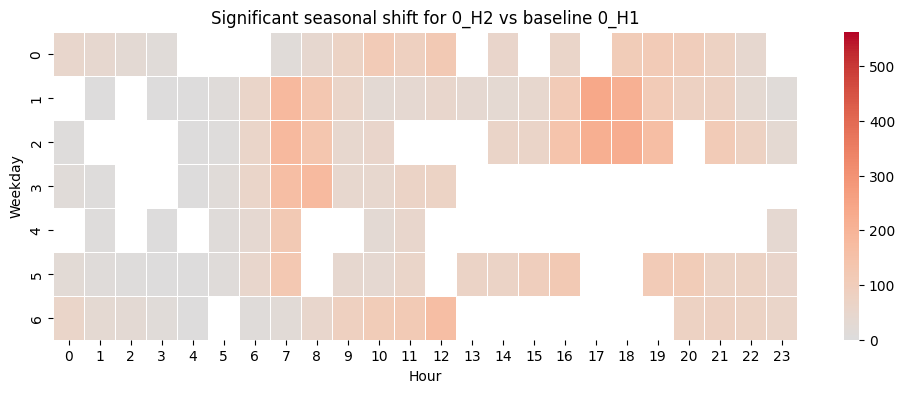

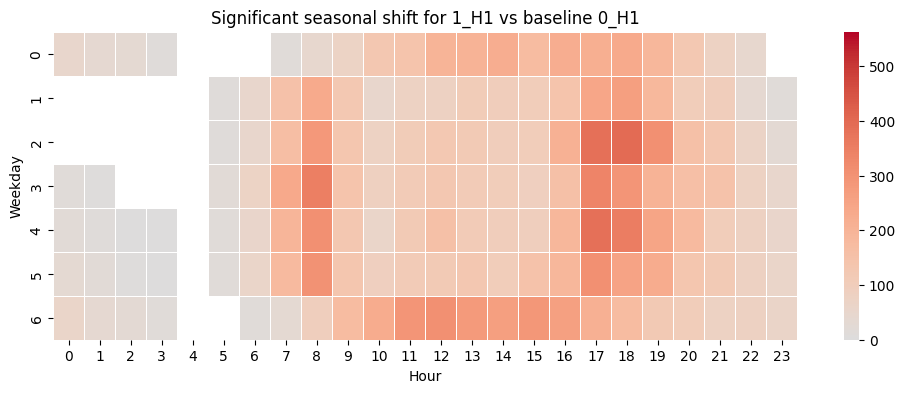

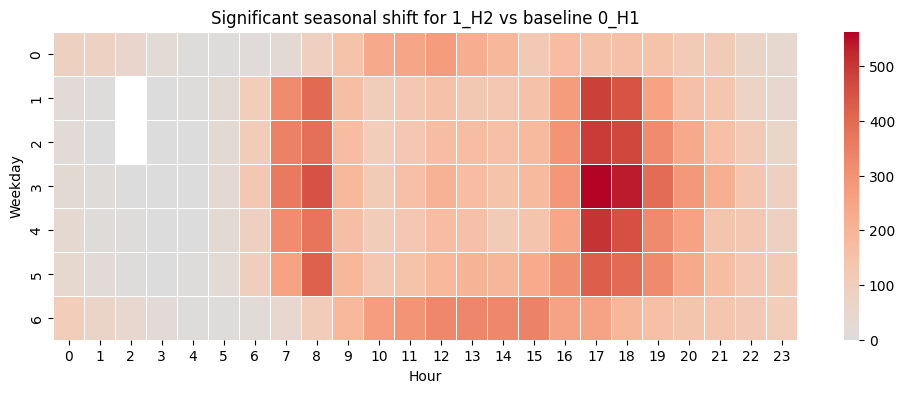

In [9]:
v_max = abs(results_df["median_diff"]).max()
v_min = abs(results_df["median_diff"]).min()

for p in sorted(results_df["period"].unique()):
    median_shift = (
        results_df[results_df.period == p]
        .pivot(index="weekday", columns="hr", values="median_diff")
    )

    pvals = (
        results_df[results_df.period == p]
        .pivot(index="weekday", columns="hr", values="pval")
    )

    mask = pvals > 0.05

    plt.figure(figsize=(12,4))

    sns.heatmap(
        median_shift,
        cmap="coolwarm",
        center=0,
        vmin=v_min,
        vmax=v_max,
        mask=mask,
        linewidths=0.5
    )

    plt.title(f"Significant seasonal shift for {p} vs baseline {baseline_period}")
    plt.xlabel("Hour")
    plt.ylabel("Weekday")

    plt.show()

Analysis:
- Compared with baseline (2011_H1), later periods show increasingly strong and statistically significant demand shifts.
- The largest increases are concentrated in morning (7–9) and evening (17–19) commuting hours, while off-peak hours show relatively smaller changes.
- The magnitude and coverage of these shifts expand over time (2011_H1 < 2011_H2 < 2012_H1 < 2012_H2).

Conclusion: 
- Demand growth is **not uniform over time**; it is primarily driven by increased usage during commuting hours. 
- This suggests a structural shift toward bikes being used as a **transportation** mode rather than leisure activity.

Insights:
- Using a fixed seasonal pattern (e.g., weekday × hour) is insufficient, as seasonality itself evolves over time.
- Ignoring this shift can lead to biased modeling and incorrect interpretation of demand drivers.

## 1.2 Naive removal vs STL

### 1.2.1 Limitations of Fixed Seasonal Mean Removal

In [10]:
# hour x day of week seasonality removal
seasonal_stats = (
    df.groupby(['weekday','hr'])['cnt']
      .agg(['mean'])
      .reset_index()
)

df_temp = df.merge(seasonal_stats, on=['weekday','hr'])
df_temp['residual'] = (df_temp['cnt'] - df_temp['mean']) 

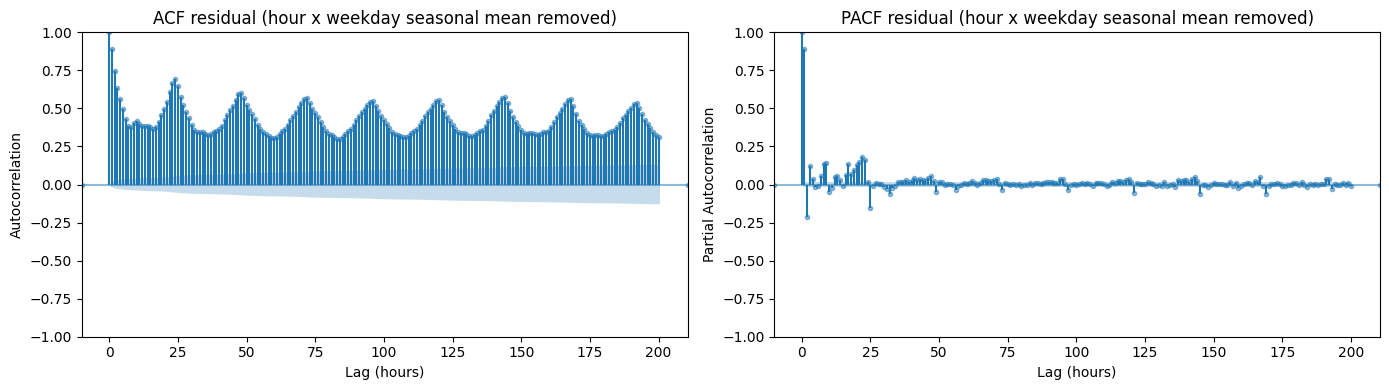

In [11]:
plot1(200, df_temp['residual'], "residual (hour x weekday seasonal mean removed)")

Analysis: 
- Removing weekday × hour mean eliminates the average seasonal level but fails to remove higher-order temporal dependencies. 
- The ACF still shows strong periodic patterns (clear waves every ~24 lags), indicating remaining seasonality and temporal correlation.
- This method also does not remove the long-term trend.

> Conclusion: simple weekday x hour mean removal **cannot** prepare the residual properly for downstream analysis.

## 1.3 STL Decomposition

In [12]:
stl = STL(df["cnt"], period=168, robust=True) # 168 = 7 days × 24 hours
result = stl.fit()

df["trend"] = result.trend
df["seasonal"] = result.seasonal
df["residual"] = result.resid

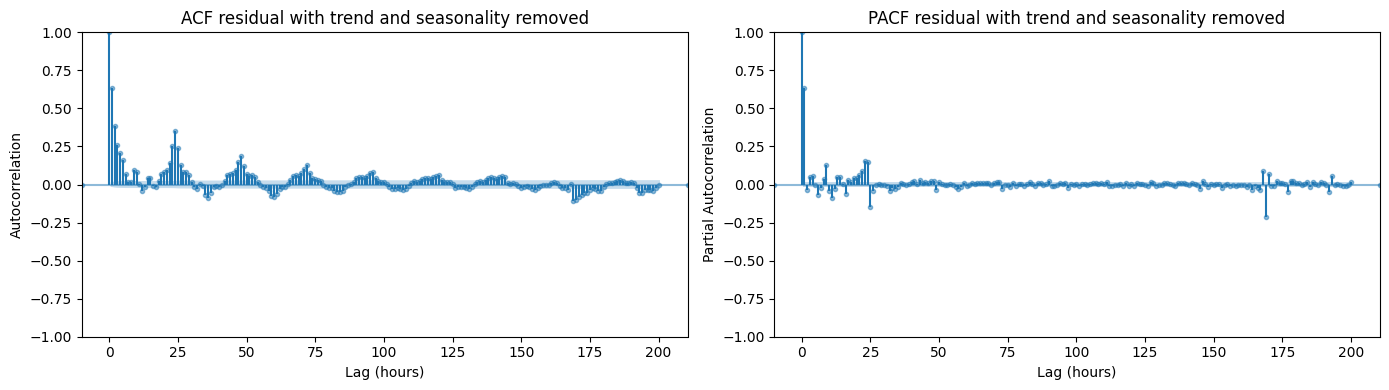

In [13]:
plot1(200, df['residual'], "residual with trend and seasonality removed")

Analysis: 
- STL decomposition removes both long-term trend and weekly seasonal structure, isolating residual demand.
- The residual represents **unexpected deviations from typical demand at that time**, after accounting for systematic patterns.
- Compared with simple seasonal mean removal, STL produces a much cleaner residual with reduced autocorrelation.
- Residual still exhibits mild short-term autocorrelation, indicating remaining structure that may be explained by external factors such as weather.

In [14]:
res1 = adfuller(df['residual'].dropna())

print("ADF Statistic:", res1[0])
print("p-value:", res1[1])
print("Used lags:", res1[2])
print("Number of observations:", res1[3])
print("Critical Values:", res1[4])

ADF Statistic: -14.95819481825645
p-value: 1.250929282181124e-27
Used lags: 44
Number of observations: 17334
Critical Values: {'1%': np.float64(-3.430727308679485), '5%': np.float64(-2.861706755762842), '10%': np.float64(-2.566858759781439)}


Analysis:
- The residual is stationary (ADF p-value ≈ 0), confirming successful removal of non-stationary components.

In [15]:
t = np.arange(len(df))
X = sm.add_constant(t)

model = sm.OLS(df["residual"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               residual   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     46.08
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.17e-11
Time:                        23:13:11   Log-Likelihood:                -99353.
No. Observations:               17379   AIC:                         1.987e+05
Df Residuals:                   17377   BIC:                         1.987e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6337      1.116      6.842      0.0

Analysis:
- A small but statistically significant trend remains (p < 0.001), though its magnitude is negligible (R² ≈ 0.003). This indicates that most of the trend has been removed, and remaining drift is minimal.

> Conclusion: As STL-based residuals removed most of trend and estimated seasonal structure, we will use STL-based residuals as the target for downstream analysis, ensuring that feature effects are evaluated on true demand deviations.

-------

# Part 2: Quantifying the Impact of External Factors on Demand Deviations

Key idea:  
**Demand = trend + seasonal structure + demand deviations**

Note: The quantified effects represent conditional demand deviations rather than additive contributions. Interactions between variables may influence demand jointly, as illustrated by the temperature–humidity analysis.

## 2.1 Weather Category

### 2.1.1 Statistical Evidence of Weather Impact

In [16]:
weather_map = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}
df["weather_label"] = df["weathersit"].map(weather_map)
df["is_rain"] = df["weathersit"] == 3

In [17]:
df["weather_label"].value_counts()

weather_label
Clear              11413
Mist/Cloudy         4544
Light Rain/Snow     1419
Heavy Rain/Snow        3
Name: count, dtype: int64

Analysis:
- Given the highly imbalanced sample size for extreme weather (category 4), results are primarily driven by categories 1–3.

In [18]:
# H0: all weather categories have same distribution
from scipy.stats import kruskal # not-normal, >2 groups
groups = [
    df[df.weathersit == i]["residual"]
    for i in sorted(df.weathersit.unique())
]

kruskal(*groups)

KruskalResult(statistic=np.float64(1117.1887468938148), pvalue=np.float64(6.79105965757543e-242))

Analysis: 
- test strongly rejects the null hypothesis (p ≈ 0), indicating that weather conditions significantly affect demand deviations.
- This confirms that weather is a key driver of short-term demand fluctuations beyond seasonal expectations.

### 2.1.2 Effect Size on Demand Deviations

In [19]:
df.groupby("weathersit")["residual"].median()

weathersit
1     1.391157
2    -0.632342
3   -17.550234
4   -17.166649
Name: residual, dtype: float64

Analysis: 
- Rainy conditions (category 3) reduce demand by approximately **17–18 bikes per hour relative to expected levels**, representing a substantial negative deviation.
- Clear weather shows a small positive deviation (~+1.4), suggesting that favorable weather slightly improve demand above baseline expectations.
- The magnitude of negative impact under adverse weather is significantly larger than the positive impact under favorable conditions.

### 2.1.3 Weather Impact on Demand Shock Probabilities

Note: Demand shocks are defined as observations in the top and bottom 10% of residuals.

In [21]:
p90 = df.residual.quantile(0.9)
p10 = df.residual.quantile(0.1)

df["pos_shock"] = df.residual > p90
df["neg_shock"] = df.residual < p10

df["shock_type"] = "Normal"
df.loc[df["pos_shock"], "shock_type"] = "Positive Shock"
df.loc[df["neg_shock"], "shock_type"] = "Negative Shock"

print(df.groupby("weathersit")["pos_shock"].mean())
print(df.groupby("weathersit")["neg_shock"].mean())

weathersit
1    0.115920
2    0.085827
3    0.017618
4    0.000000
Name: pos_shock, dtype: float64
weathersit
1    0.062122
2    0.109155
3    0.375617
4    0.000000
Name: neg_shock, dtype: float64


Analysis:
- The probability of positive demand shocks decreases sharply as weather worsens: from (Clear: ~11.6%) to (Rain: ~1.8%)
- Conversely, the probability of negative demand shocks increases dramatically as weather worsens: from (Clear: ~6%) to (Rain: ~37.6%)
- This indicates that adverse weather not only lowers average demand but also **increases downside risk**, while favorable weather mainly increases upside potential.
- The zero probability of positive and negative demand shocks for extreme weather (category 4) is due to extreme small sample size (3 out of 17379 data).

### 2.1.4 Conclusion
1. Adverse weather (no extreme) has a strong asymmetric impact on demand:

    - Rain reduces demand by approximately **17–18 bikes per hour** relative to expected levels.
    - It also increases the probability of large negative demand shocks **from 6% to 38%**.

2. Favorable weather provides only a **modest uplift in average demand** (~+1.4), but significantly increases the likelihood of positive demand shocks, **from 2% to 12%**.

**Operational Implications:**
1. Weather-informed bike redistribution

    Rainy weather reduces demand by approximately **17–18 bikes per hour relative to seasonal expectations**. This provides a practical guideline for rebalancing decision. For example, when rain is forecasted, stations in affected areas may experience roughly **15–20 fewer rentals** per hour, suggesting that excess bikes can be proactively relocated to higher-demand locations.

    > This estimate should be used as a planning reference rather than a fixed rule, as demand still varies by time and location.

2. Weather-aware maintenance scheduling

    Adverse weather reduces demand by approximately **15–20 rentals per hour relative to expected levels**, creating a window for maintenance operations. For example, if rain is forecasted, operators can schedule bike collection or repairs in advance, as temporarily removing bikes from service is less likely to create supply shortages.

    > This estimate should be used as a planning reference rather than a fixed rule, as demand still varies by time and location.

3. Preparing for demand spikes under favorable weather

    clear weather increases the probability of positive demand shocks **from ~2% to ~12%**, indicating a higher likelihood of unexpectedly high demand. Operators can increase bike availability or redistribution frequency to capture this additional demand.

-------

## 2.2 Temperature

### 2.2.1 data selection and processing

As `atemp` means temperature felt like for human, and people riding bike will have a strong feeling on `atemp`. We will use `atemp` instead of `temp`.

In [22]:
df[["temp","atemp"]].corr()

,temp,atemp
temp,1.000000,0.987672
atemp,0.987672,1.000000


In [23]:
# Transform atemp back to Celsius for interpretability
def denormalize_atemp(atemp_norm):
    t_min = -16
    t_max = 50
    return atemp_norm * (t_max - t_min) + t_min
df["atemp_c"] = denormalize_atemp(df["atemp"])

### 2.2.2 Nonlinear Relationship (LOWESS)

LOWESS (Locally Weighted Scatterplot Smoothing) is a non-parametric method that fits a smooth curve by locally weighting nearby observations. 

We use LOWESS here to capture the nonlinear relationship between perceived temperature and demand deviations without imposing a fixed functional form (e.g., linear or quadratic), allowing the data to reveal turning points and optimal temperature ranges.

In [24]:
lowess = sm.nonparametric.lowess(
    df["residual"],
    df["atemp_c"],
    frac=0.2
)

In [25]:
lowess_df = pd.DataFrame({
    "atemp_c": lowess[:, 0],
    "lowess_residual_temp": lowess[:, 1]
})

lowess_df.to_csv("lowess_curve.csv", index=False)

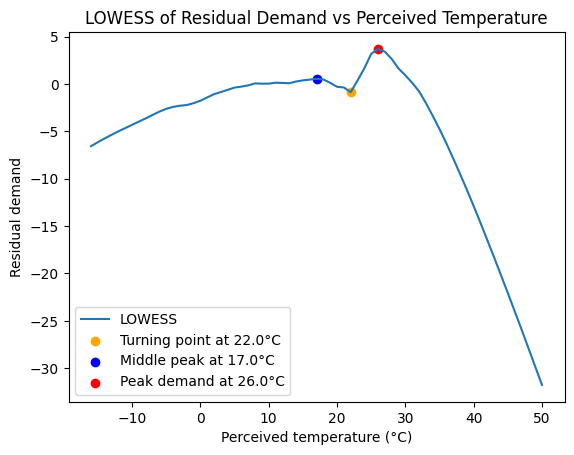

In [26]:
temps = lowess[:,0]
residuals = lowess[:,1]


# find local minimum in the middle range (15-24°C)
mask = (temps > 15) & (temps < 24)
idx_min = np.argmin(residuals[mask])
valley_idx = np.where(mask)[0][idx_min]
valley_temp = temps[valley_idx]

# find local maximum in the middle range (10-20°C)
mask = (temps > 10) & (temps < 20)
idx_max = np.argmax(residuals[mask])
mid_peak_idx = np.where(mask)[0][idx_max]
mid_peak_temp = temps[mid_peak_idx]

# find global maximum (peak demand)
peak_idx = np.argmax(residuals)
peak_temp = temps[peak_idx]

#plotting
plt.plot(temps, residuals, label="LOWESS")
plt.scatter(
    valley_temp,
    residuals[valley_idx],
    color="orange",
    label=f"Turning point at {valley_temp:.1f}°C"
)
plt.scatter(
    mid_peak_temp,
    residuals[mid_peak_idx],
    color="blue",
    label=f"Middle peak at {mid_peak_temp:.1f}°C"
)
plt.scatter(
    peak_temp,
    residuals[peak_idx],
    color="red",
    label=f"Peak demand at {peak_temp:.1f}°C"
)
plt.xlabel("Perceived temperature (°C)")
plt.ylabel("Residual demand")
plt.legend()
plt.xlabel("Perceived temperature (°C)")
plt.ylabel("Residual demand")
plt.title("LOWESS of Residual Demand vs Perceived Temperature")

plt.legend()
# plt.savefig("figures/temp_residual_lowess.png")

Analysis:
- Demand deviations increase as temperature rises from cold conditions and reach a local peak around **17°C**., consistent with reduced cycling activity during colder weather.
- A temporary decline occurs between **17–22°C**, indicating a transition region.
- Demand then increases sharply and reaches its maximum around **26°C**, suggesting an optimal temperature range for cycling.
- Beyond 26°C, demand declines rapidly, indicating that excessive heat discourages bike usage.

In [27]:
# marker_df = pd.DataFrame({
#     "atemp_c": [17, 22, 26],
#     "residual_smooth": [
#         lowess[np.argmin(abs(lowess[:,0]-17)),1],
#         lowess[np.argmin(abs(lowess[:,0]-22)),1],
#         lowess[np.argmin(abs(lowess[:,0]-26)),1]
#     ],
#     "point_type": ["Mid Peak", "Dip", "Peak"]
# })
# marker_df.to_csv("lowess_markers.csv", index=False)

### 2.2.3 Effect Size by Temperature Range

In [28]:
bins = [-20,5,10,17,22,26,30,60]
labels = [
    "very_cold (<5°C)",
    "cold (5-10°C)",
    "cool (10-17°C)",
    "moderate (17-22°C)",
    "warm (22-26°C)",
    "hot (26-30°C)",
    "extreme hot (>30°C)"
]

df["temp_bin"] = pd.cut(df["atemp_c"], bins=bins, labels=labels)
df["temp_bin_order"] = pd.Categorical(
    df["temp_bin"],
    categories=[
        "very_cold (<5°C)",
        "cold (5-10°C)",
        "cool (10-17°C)",
        "moderate (17-22°C)",
        "warm (22-26°C)",
        "hot (26-30°C)",
        "extreme hot (>30°C)"
    ],
    ordered=True
)
df.groupby("temp_bin_order")["residual"].median()

C:\Users\heiha\AppData\Local\Temp\ipykernel_36912\3213096944.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("temp_bin_order")["residual"].median()


temp_bin_order
very_cold (<5°C)      -1.207869
cold (5-10°C)          0.314895
cool (10-17°C)         0.529000
moderate (17-22°C)    -1.051689
warm (22-26°C)         1.145675
hot (26-30°C)          4.091121
extreme hot (>30°C)   -1.744212
Name: residual, dtype: float64

In [29]:
df["residual"].max()

np.float64(589.4553402075086)

Analysis: 
- Very cold (<5°C) and extreme hot (>30°C) conditions both show negative demand deviations, indicating suppressed demand (~-1.2 for cold and ~-1.7 for hot).
- The 17–22°C range also exhibit negative deviations (~−1), suggesting that **favorable temperature alone does not guarantee increased demand**.
- Warm to hot conditions (22–30°C) show the strongest positive effects, with up to +4 rentals per hour. 


### 2.2.4 Shock Analysis

In [30]:
print(df.groupby("temp_bin")["pos_shock"].mean(), "\n")
print(df.groupby("temp_bin")["neg_shock"].mean())

temp_bin
very_cold (<5°C)       0.083888
cold (5-10°C)          0.119597
cool (10-17°C)         0.115958
moderate (17-22°C)     0.075895
warm (22-26°C)         0.091219
hot (26-30°C)          0.137806
extreme hot (>30°C)    0.074719
Name: pos_shock, dtype: float64 

temp_bin
very_cold (<5°C)       0.108655
cold (5-10°C)          0.113353
cool (10-17°C)         0.107123
moderate (17-22°C)     0.126136
warm (22-26°C)         0.077153
hot (26-30°C)          0.050442
extreme hot (>30°C)    0.107865
Name: neg_shock, dtype: float64


C:\Users\heiha\AppData\Local\Temp\ipykernel_36912\2123503392.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("temp_bin")["pos_shock"].mean(), "\n")
C:\Users\heiha\AppData\Local\Temp\ipykernel_36912\2123503392.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("temp_bin")["neg_shock"].mean())


Analysis:
- The 26–30°C range has the highest probability of positive demand shocks (~13.8%) and the lowest probability of negative shocks.
- The 17–22°C range shows the highest probability of negative demand shocks (~13%) and nearly lowest positive shock probability(~7%).
- This suggests that warm temperatures increase both demand level and upside variability, while moderate temperatures are associated with more uncertainty and downside risk.

### 2.2.5 Conclusion

1. Temperature has a strong nonlinear impact on demand, with demand peaking around **26°C** and declining under both cold and extreme hot conditions. 
2. The **17–22°C range** represents a transition zone, showing negative demand deviations and the highest probability of negative demand shocks, suggesting the influence of additional interacting factors.
3. The **26–30°C range** not only increases average demand (~+4 rentals per hour) but also produces the highest probability of positive demand shocks (~13.8%), indicating increased likelihood of demand surges.

**Operational Implications**
1. Capacity planning for warm conditions 

    When temperatures are forecasted to be in the **26–30°C range**, operators should anticipate higher demand (~4 more rentals per hour) and increased likelihood of demand spikes. This suggests maintaining higher bike availability or increasing redistribution frequency to capture additional demand. 



-----

## 2.3 Contribution of Rider Types to Demand Deviations

### 2.3.1 Residual Processing

To understand which rider group drives demand deviations, we apply STL decomposition separately to casual and registered counts. This provides an approximate decomposition of demand deviations by rider type. While STL is not strictly additive across separately decomposed series, this approach offers a practical way to analyze how each group contributes to overall demand fluctuations.

In [31]:
# Casual decomposition
stl_casual = STL(df["casual"], period=168, robust=True)
result_casual = stl_casual.fit()

df["casual_residual"] = result_casual.resid


# Registered decomposition
stl_registered = STL(df["registered"], period=168, robust=True)
result_registered = stl_registered.fit()

df["registered_residual"] = result_registered.resid

### 2.3.2 Contribution to Demand Shocks

Key Idea:
**total deviation ≈ casual deviation + registered deviation**

In [32]:
p90 = df.residual.quantile(0.9)
p10 = df.residual.quantile(0.1)

df["pos_shock"] = df.residual > p90
df["neg_shock"] = df.residual < p10
print("positive shocks:")
print(df[df.pos_shock][["casual_residual","registered_residual"]].mean()) #E[casual deviation ∣ positive shock]
print("-"*40)
print("negative shocks:")
print(df[df.neg_shock][["casual_residual","registered_residual"]].mean()) #E[registered deviation ∣ negative shock]
print("-"*40)

pos = df[df.pos_shock]
neg = df[df.neg_shock]

pos_share_registered = abs(pos.registered_residual).sum() / (
    abs(pos.registered_residual).sum() +
    abs(pos.casual_residual).sum()
)

neg_share_registered = abs(neg.registered_residual).sum() / (
    abs(neg.registered_residual).sum() +
    abs(neg.casual_residual).sum()
)

print("registered share in positive shocks: "+str(round(pos_share_registered, 2)*100)+"%")
print("registered share in negative shocks: "+str(round(neg_share_registered, 2)*100)+"%")

positive shocks:
casual_residual         29.021968
registered_residual    101.660430
dtype: float64
----------------------------------------
negative shocks:
casual_residual        -21.460051
registered_residual   -100.187684
dtype: float64
----------------------------------------
registered share in positive shocks: 77.0%
registered share in negative shocks: 81.0%


Analysis
- Registered riders account for the majority of demand deviations during shocks:
    - ~77% of positive shocks
    - ~81% of negative shocks
- This suggests that large fluctuations in demand are primarily driven by changes in registered rider activity.


### 2.3.3 Conclusion
1. Demand shocks are primarily driven by registered riders, who account for approximately **77% of positive** and **81% of negative demand deviations**.
2. This indicates that large fluctuations in total demand are largely determined by variability in commuter (registered) rider behavior rather than casual usage.

**Operational Implication**
1. Prioritize registered rider demand in operational planning
    - Since demand fluctuations are primarily driven by registered riders, bike redistribution strategies should focus on commuter-heavy periods and locations. Monitoring patterns associated with registered users can improve responsiveness to both demand surges and drops.

-----

## 2.4 Temperature Transition Zone (17–22°C) Explaination

#### 2.4.1 Weather Category 

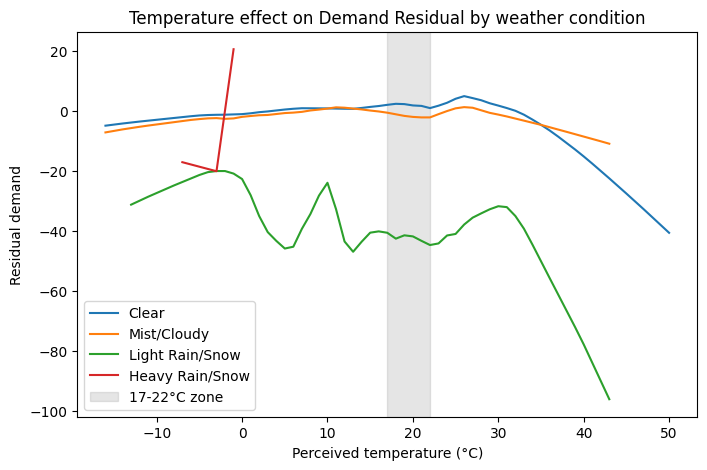

In [33]:
plt.figure(figsize=(8,5))

weather_labels = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

for w in sorted(df["weathersit"].unique()):
    
    subset = df[df["weathersit"] == w]
    
    lowess = sm.nonparametric.lowess(
        subset["residual"],
        subset["atemp_c"],
        frac=0.2
    )
    
    plt.plot(lowess[:,0], lowess[:,1], label=weather_labels.get(w, f"Weather {w}"))

plt.axvspan(17,22, color='gray', alpha=0.2, label="17-22°C zone")

plt.xlabel("Perceived temperature (°C)")
plt.ylabel("Residual demand")
plt.title("Temperature effect on Demand Residual by weather condition")
plt.legend()
plt.show()

Analysis:
- The temperature–demand relationship shows a downward slope in the 17–22°C range across all weather conditions.
- Under light rain/snow (category 3), this decline is **steeper**, indicating that adverse weather amplifies negative demand deviations.

In [34]:
model = smf.ols(
    "residual ~ atemp_c + C(weathersit) + atemp_c:C(weathersit)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               residual   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     202.8
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.61e-290
Time:                        23:18:24   Log-Likelihood:                -98693.
No. Observations:               17379   AIC:                         1.974e+05
Df Residuals:                   17371   BIC:                         1.975e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

Analysis
- The interaction term for rain (atemp × weather=3) is significantly negative (−0.575, p=0.005), indicating a stronger negative temperature effect under rainy conditions. 

**Conclusion: Weather does not explain the existence of the transition zone (17-22°C), but adverse weather conditions amplify the negative deviation within this range.**

#### 2.4.2 Rider Type

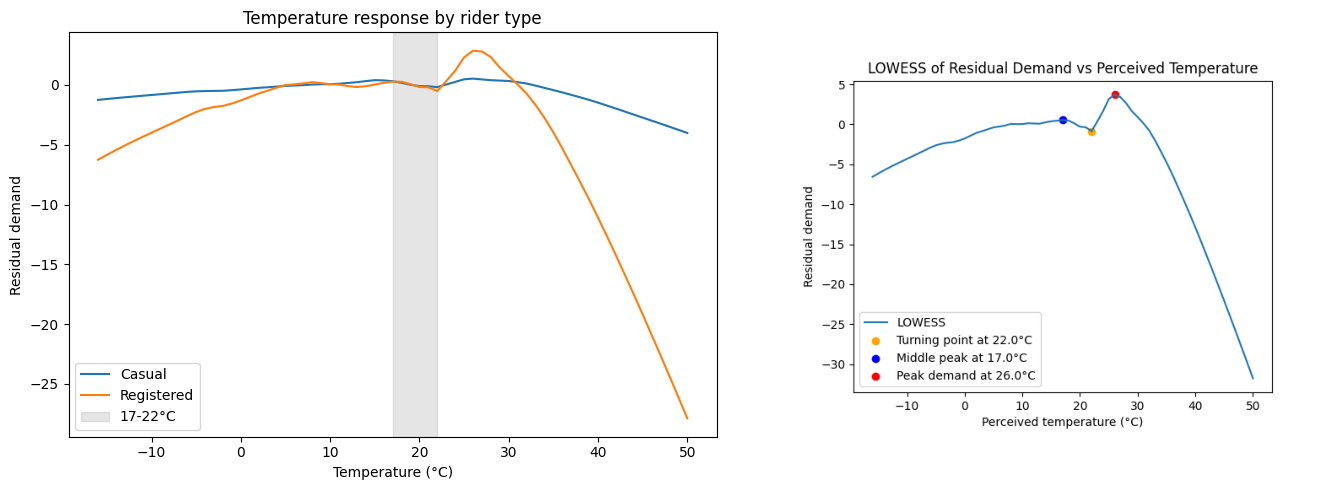

In [35]:
lowess_casual = sm.nonparametric.lowess(
    df["casual_residual"],
    df["atemp_c"],
    frac=0.2
)

lowess_registered = sm.nonparametric.lowess(
    df["registered_residual"],
    df["atemp_c"],
    frac=0.2
)

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: your LOWESS plot ----
axes[0].plot(lowess_casual[:,0], lowess_casual[:,1], label="Casual")
axes[0].plot(lowess_registered[:,0], lowess_registered[:,1], label="Registered")

axes[0].axvspan(17, 22, color="gray", alpha=0.2, label="17-22°C")

axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Residual demand")
axes[0].set_title("Temperature response by rider type")
axes[0].legend()

# ---- Right: load and show image ----
img = plt.imread("figures/temp_residual_lowess.png")
axes[1].imshow(img)
axes[1].axis("off")
# axes[1].set_title("LOWESS of Residual Demand vs Perceived Temperature")

# Adjust layout
plt.tight_layout()
plt.show()

Analysis: 
- The 17–22°C dip appears in both casual and registered rider residuals.
- The overall shape of the registered curve closely matches the total demand residual pattern.
- This indicates that the transition pattern is not driven by a specific rider group, but is shared across both user types.

**Conclusion: The transition zone is not attributable to a single rider group, suggesting that the effect reflects a broader behavioral response rather than group-specific dynamics.**

#### 2.4.3 Humidity

In [36]:
df["hum_pct"] = df["hum"] * 100
df.groupby("temp_bin")["hum_pct"].median()

C:\Users\heiha\AppData\Local\Temp\ipykernel_36912\2256173639.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("temp_bin")["hum_pct"].median()


temp_bin
very_cold (<5°C)       59.0
cold (5-10°C)          66.0
cool (10-17°C)         67.0
moderate (17-22°C)     78.0
warm (22-26°C)         69.0
hot (26-30°C)          58.0
extreme hot (>30°C)    53.0
Name: hum_pct, dtype: float64

Analysis: Humidity increases with temperature and peaks in the 17–22°C range (~78–80%).

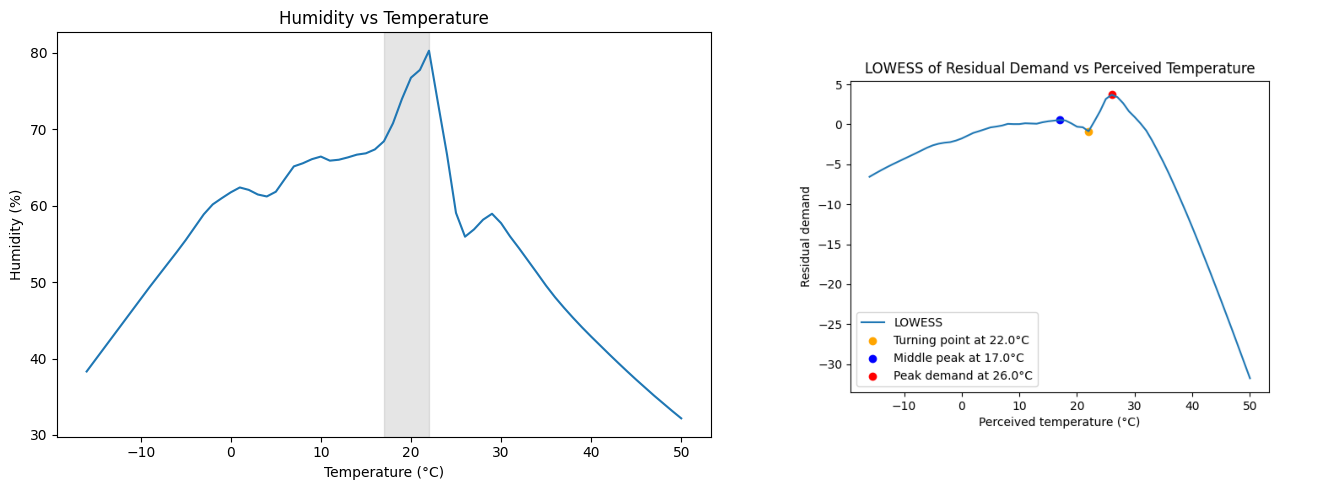

In [37]:
lowess = sm.nonparametric.lowess(
    df["hum_pct"],
    df["atemp_c"],
    frac=0.2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lowess[:,0], lowess[:,1])
axes[0].axvspan(17, 22, color="gray", alpha=0.2)
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Humidity (%)")
axes[0].set_title("Humidity vs Temperature")

img = plt.imread("figures/temp_residual_lowess.png")
axes[1].imshow(img)
axes[1].axis("off")

plt.tight_layout()
plt.show()

Analysis:
- The LOWESS curve shows that humidity increases sharply as temperature approaches the 17–22°C range, reaching its peak within this interval.
- At the same time, demand deviations begin to decline within this range, reversing the earlier increasing trend from colder temperatures.
- Beyond 22°C, humidity starts to decrease, and demand deviations increase again toward their peak around 26°C.
- This synchronized change suggests that **the transition pattern in demand is closely associated with changes in humidity rather than temperature alone.**
- The overlap between peak humidity and reduced demand suggests that high humidity may suppress cycling activity, even when temperatures are moderate.

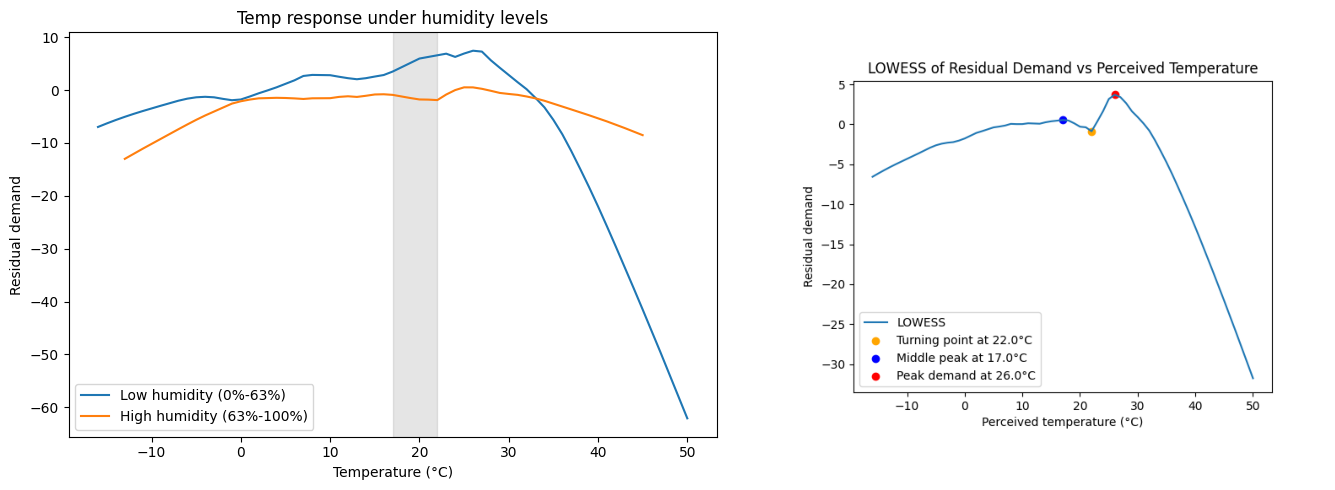

In [38]:
df["hum_group"] = pd.qcut(df["hum_pct"], q=2, labels=["Low humidity","High humidity"])
labels = ["Low humidity", "High humidity"]
cuts = pd.qcut(df["hum_pct"], q=2)

label_map = {}
for label, interval in zip(labels, cuts.cat.categories):
    left = int(round(interval.left))
    right = int(round(interval.right))
    label_map[label] = f"{label} ({left}%-{right}%)"
    # print(f"{label}: {left}% - {right}%")

lowess_data = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for g in ["Low humidity", "High humidity"]:  
    subset = df[df["hum_group"] == g]
    
    lowess = sm.nonparametric.lowess(
        subset["residual"],
        subset["atemp_c"],
        frac=0.2
    )

    temp_df = pd.DataFrame(lowess, columns=["Atemp C", "Lowess Residual Temp"])
    temp_df["Humidity Group"] = g
    
    lowess_data.append(temp_df)
    
    axes[0].plot(lowess[:,0], lowess[:,1], label=label_map[g])

axes[0].axvspan(17, 22, color="gray", alpha=0.2)

axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Residual demand")
axes[0].set_title("Temp response under humidity levels")
axes[0].legend()

img = plt.imread("figures/temp_residual_lowess.png")
axes[1].imshow(img)
axes[1].axis("off")

plt.tight_layout()
plt.show()

lowess_df = pd.concat(lowess_data)
lowess_df.to_csv("lowess_temp_humidity.csv", index=False)

Analysis:
- Under low humidity conditions in 17-22°C range, demand increases with temperature as expected, showing a upward trend from cold to warm ranges.
- Under high humidity conditions in 17-22°C range, demand is consistently lower, and a clear dip appears. Right after 22°C, demand resumes increasing trend to warm temperatures.
- This contrast indicates that the non-monotonic temperature effect is primarily driven by high humidity conditions rather than temperature alone.
- In particular, the 17–22°C transition pattern becomes visible only with high humidity, reinforcing the earlier observation that humidity plays a key role in shaping demand behavior in this range.

### 2.4.4 Final Conclusion 

The temporary decline in demand within the 17–22°C range is not explained by weather categories or rider type, as the pattern is consistently observed across all weather conditions and both user groups. While adverse weather (e.g., light rain/snow) **amplifies** the negative deviation, it does not account for the existence of the transition zone itself.

Instead, the transition pattern is closely associated with humidity dynamics. Humidity rises sharply and reaches its peak within the 17–22°C range, coinciding with the point where demand deviations begin to decline. Beyond this range, humidity decreases and demand resumes its upward trend, aligning with the overall temperature–demand relationship.

Further evidence shows that the dip in demand is primarily present under high humidity conditions, while under low humidity, demand follows a normal increasing trend with temperature (before extreme hot temperature). This indicates that the observed non-monotonic pattern is conditional on elevated humidity levels, rather than driven by temperature alone.

> **Overall, the transition zone reflects a combined environmental effect, where moderate temperatures paired with high humidity are associated with reduced cycling demand.**

(One possible explanation is that high humidity reduces sweat evaporation, causing more heat feeling and heavier sweating. Such physiological feelings may discrouage cycling activity and cause negative demand deviations)

# Part 3: Final Synthesis

Bike demand deviations are influenced by both environmental conditions and rider behavior, with weather, temperature, and rider composition playing different roles.

Adverse weather is the most direct driver of negative demand deviations, consistently pushing demand below expected levels and increasing the likelihood of negative shocks. In contrast, favorable weather does not substantially increase average deviations, but it does raise the probability of positive demand shocks. This suggests an asymmetric impact of weather on demand variability.

Temperature shapes the overall structure of demand deviations in a nonlinear way. As temperature rises from cold conditions, demand deviations generally increase and reach their highest levels under moderately warm conditions. However, this relationship is not strictly monotonic. A transition zone appears within the 17–22°C range, where demand deviations temporarily decline despite improving temperature.

This transition pattern is observed across both rider types and weather categories, indicating that it is not driven by a specific group or condition. Instead, it is closely associated with humidity. Humidity peaks within this temperature range, and higher humidity levels are linked to more negative demand deviations. This suggests that the combination of moderate temperature and high humidity is associated with reduced cycling activity relative to expected levels.

In terms of rider behavior, demand deviations are largely driven by registered users. Most large positive and negative deviations come from this group, indicating that commuter activity plays a dominant role in overall demand variability, while casual riders contribute less to these fluctuations.

Overall, demand deviations follow a layered structure: weather drives immediate shifts, temperature defines the broader pattern, rider composition determines how fluctuations are expressed, and humidity acts as a contextual factor that modifies the expected relationship between temperature and demand. Together, these factors help explain when and why demand deviates from its seasonal baseline.

### 🔑 Key Insights

- Rain leads to about **17–18 fewer rentals per hour** and sharply increases negative demand shocks (**6% → 38%**)
- Demand peaks around **26°C**, but shows an unexpected dip in the **17–22°C range**
- This transition zone is **linked to high humidity**, rather than temperature alone
- Around **80% of demand fluctuations come from registered (commuter) riders**

### 📊 Operational Takeaways
- Scale down bike allocation by ~15–20 rental/hour when rain is forecast
- Increase capacity and redistribution efforts during 26–30°C periods to capture higher demand
- Watch high-humidity days (17–22°C), as demand may drop by ~4 rental/hour unexpectedly
- Focus on commuter-heavy areas, since registered riders drive most demand variability

In [39]:
df.to_csv("hour_processed.csv", index=False)